In [1]:
import os
os.chdir('/home/slagter/Astronomy_master/STRW-MSC/SF_in_NGC')
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scripts.phot_toolkits as phot_tk
from astropy.io import fits
from astropy.stats import knuth_bin_width
from pathlib import Path
import csv
%load_ext autoreload
%autoreload 2

The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


In [23]:
JWST_files              = phot_tk.Pipeline_level_2_data(working_directory = "/net/vdesk/data2/slagter/JWST_NIRCAM_#1227_level_2/mastDownload/JWST")


Initialized data in ['F187N', 'F115W', 'F444W']


In [3]:
# JWST_files.run_pipeline_all()


In [3]:
gaia_cat_path =  str(Path(JWST_files.wdir).parent.parent) + '/ngc346_gaia_dr3_5arcmin.txt'
gaia_cat_path_clean =  str(Path(JWST_files.wdir).parent.parent) + '/ngc346_gaia_dr3_5arcmin_clean.txt'

names = ['source_id','ra','dec','parallax','pmra','pmdec',
         'phot_g_mean_mag','phot_g_mean_flux_over_error',
         'phot_bp_mean_mag','phot_bp_mean_flux_over_error',
         'phot_rp_mean_mag','phot_rp_mean_flux_over_error',
         'phot_g_mean_mag_error','phot_bp_mean_mag_error','phot_rp_mean_mag_error']

df = pd.read_csv(gaia_cat_path, sep=r'\s+', comment='#', header=None,
                 names=names, na_values=['""','"'], quoting=csv.QUOTE_NONE)
df.to_csv(gaia_cat_path_clean, sep=' ', index=False, na_rep='NaN')

Running for F115W...
    (3) Running starbug
Skipping starbug2 run
Plotting Level 2 downloaded data...


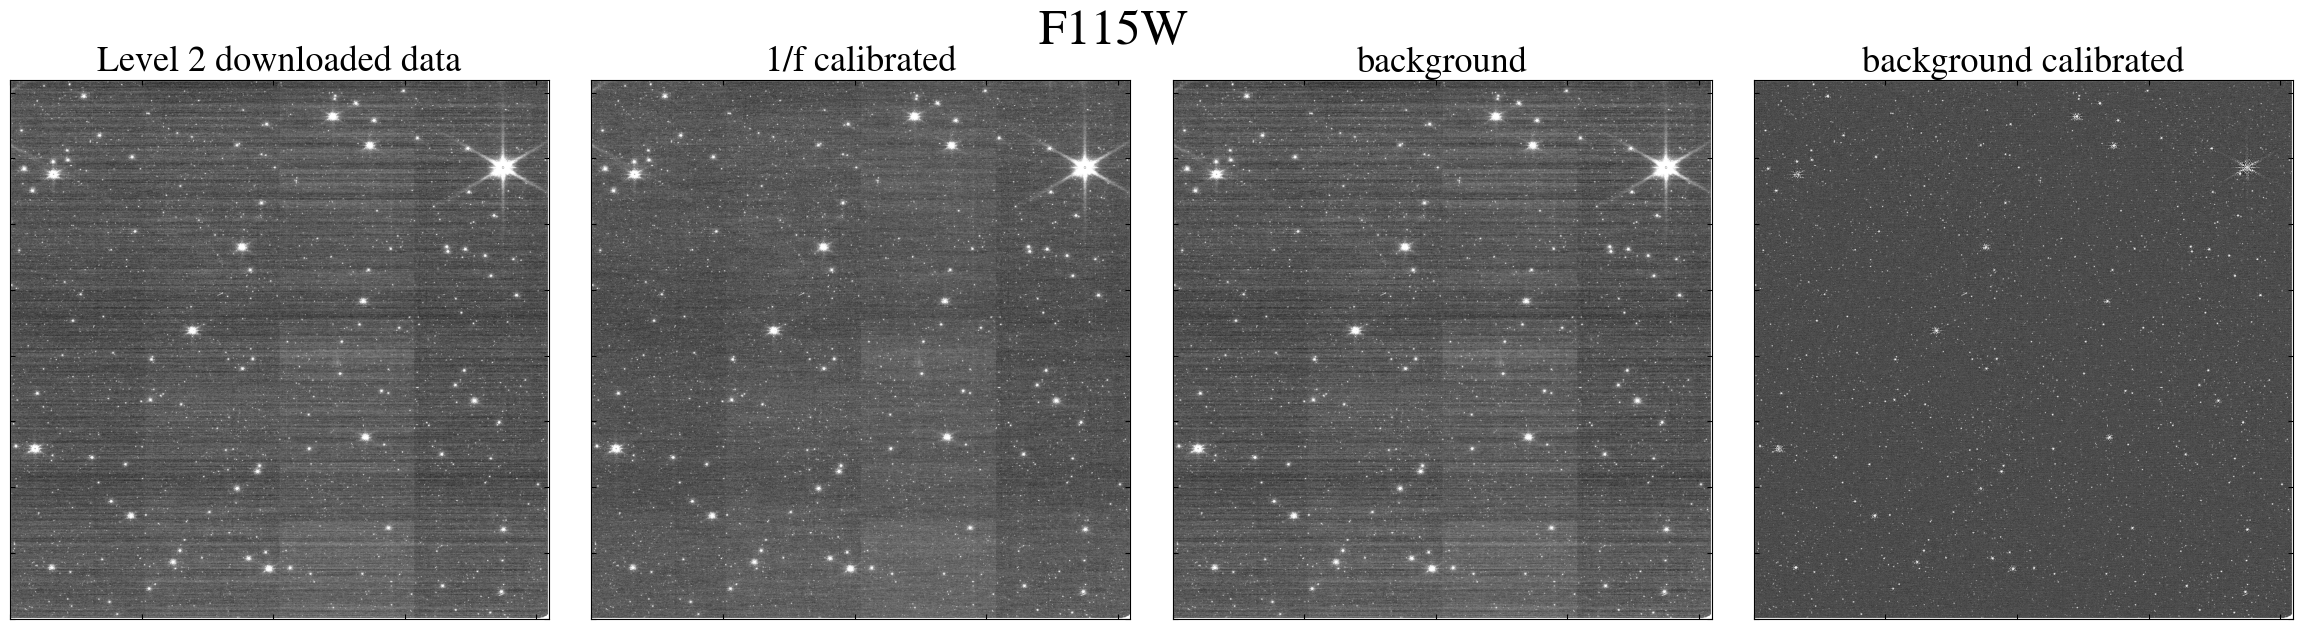

Running for F187N...
    (3) Running starbug
Skipping starbug2 run
Plotting Level 2 downloaded data...


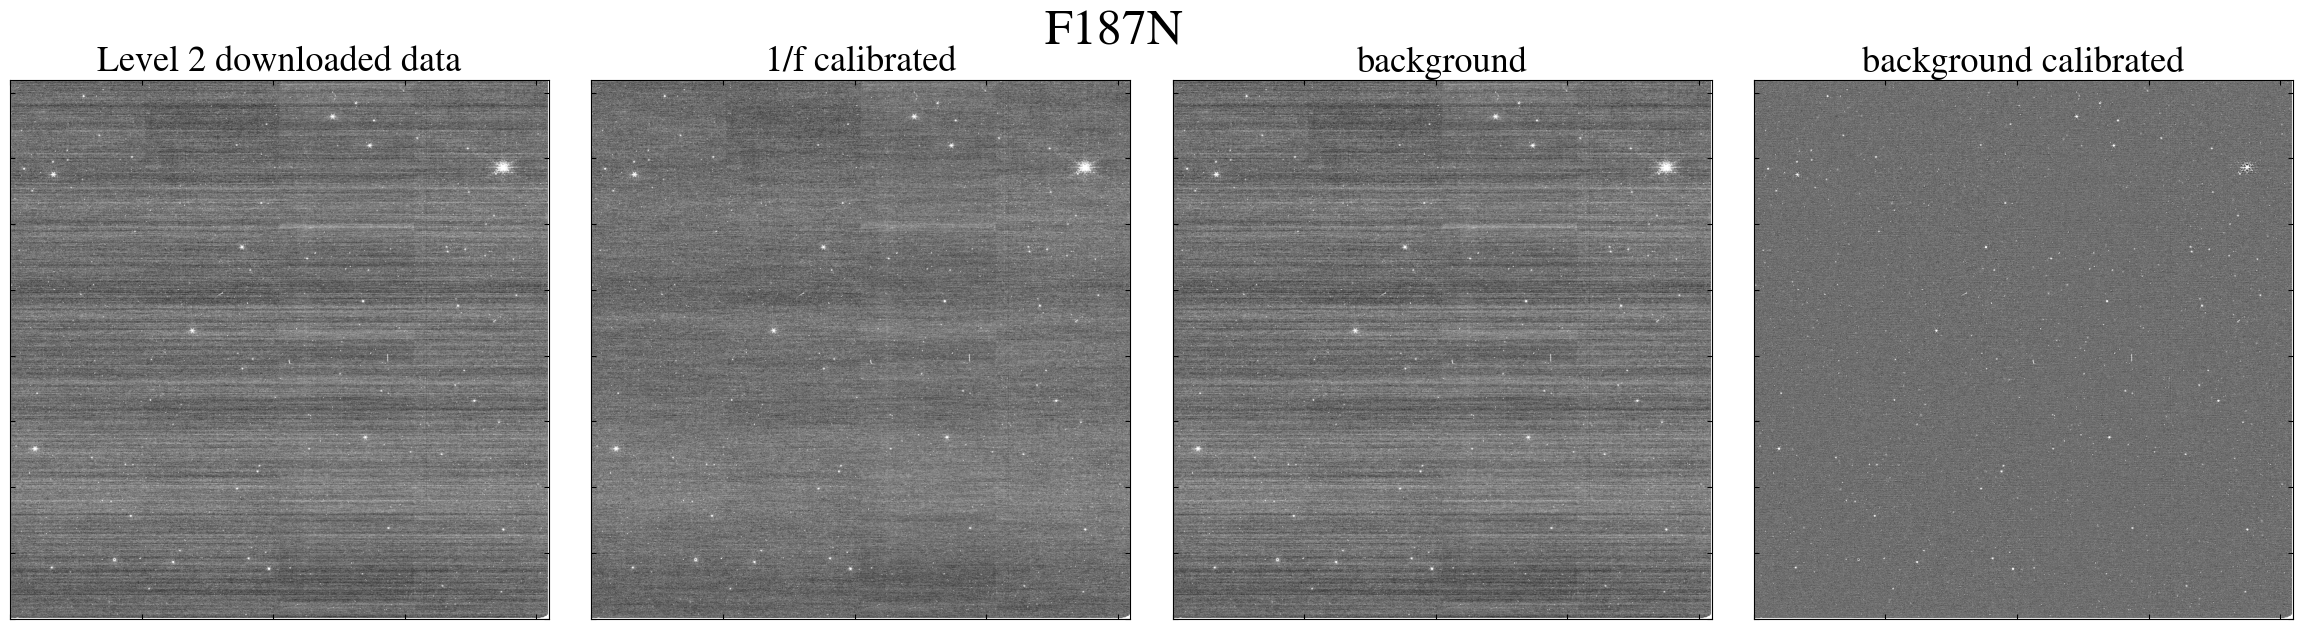

----Pipeline-----
JWST pipeline version             : 2.0.1
Calibration Reference Data System : 13.1.13
CRDS context map                  : jwst_1535.pmap
Read-out pattern                  : BRIGHT2
Number of read-out groups         : 2
----Completed----


In [35]:
JWST_files.run_pipeline_single( IMAGE_INDEX         = 30,
                                detection_sigma     = 2.0,
                                overwrite_always_run= False,
                                save                = True,)


array([14.6934542, 14.6899492, 14.6940897, ..., 14.6865457, 14.6971636,
       14.6855896], shape=(7038,), dtype='>f8')

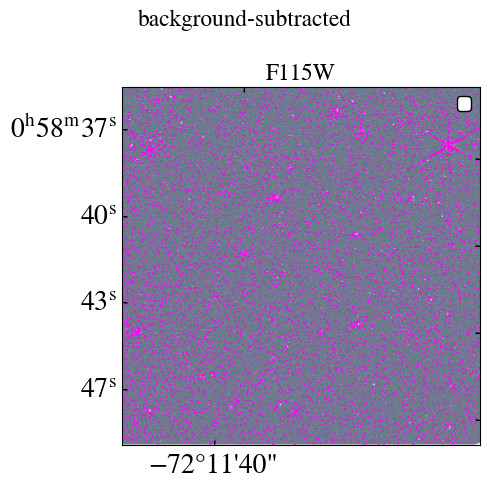

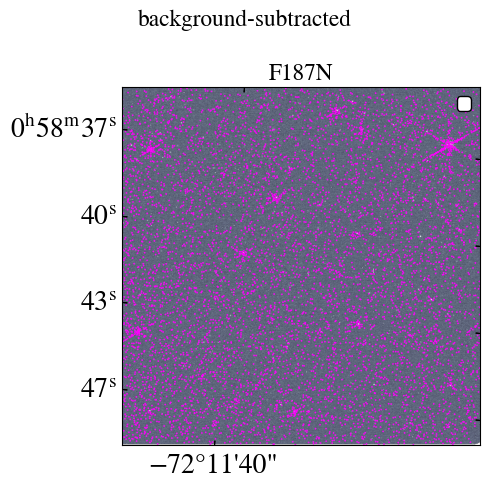

In [78]:
IMAGE_INDEX = 30

RA_min, RA_max  = JWST_files.aperture_data['F115W'].RA.min(), JWST_files.aperture_data['F115W'].RA.max()
DEC_min, DEC_max  = JWST_files.aperture_data['F115W'].DEC.min(), JWST_files.aperture_data['F115W'].DEC.max()

catalogue_path  = 'Photometry/NGC346_NIRCam_and_MIRI_Public_JWST_Catalogue.fits'
Catalogue       = phot_tk.Read_Catalogue(catalogue_path = catalogue_path)
Catalogue.mask_region(RA = (RA_min, RA_max ), DEC = (DEC_min, DEC_max))

specific_ra_dec = np.vstack([Catalogue.sub_cat_data['ra'], Catalogue.sub_cat_data['dec']])

JWST_files.show_detections( filters             = ['F115W', 'F187N'],
                            image_type          = 'bgsub',
                            IMAGE_INDEX         = IMAGE_INDEX,
                            draw_detections     = False,
                            specific_ra_dec     = specific_ra_dec,#np.array([[], []]), #
                            marker_radius_pixel = 3,
                            save                = True,
                            save_dir            = 'Plots')




In [17]:
catalogue_path  = 'Photometry/NGC346_NIRCam_and_MIRI_Public_JWST_Catalogue.fits'
Catalogue       = phot_tk.Read_Catalogue(catalogue_path = catalogue_path)
Catalogue.mask_region(RA = (RA_min, RA_max ), DEC = (DEC_min, DEC_max))


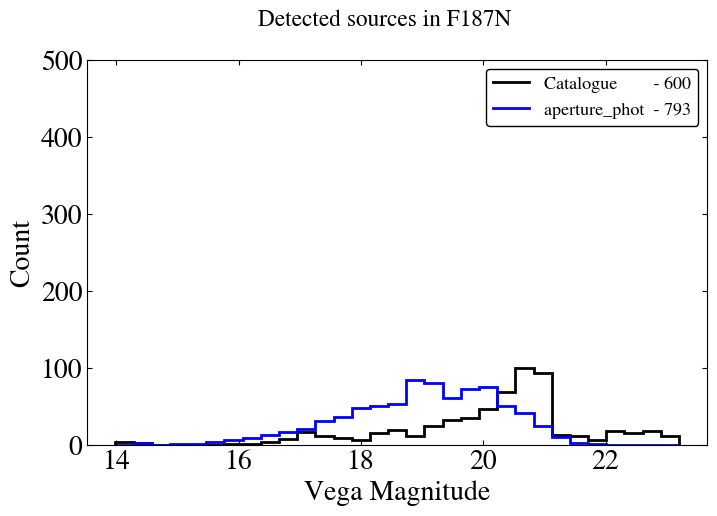

In [20]:
fig = plt.figure()
gs = fig.add_gridspec(1, 1, figure=fig, wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])


filter  = 'F187N'
mask    = Catalogue.sub_cat_data[filter] < 50
samples = Catalogue.sub_cat_data[filter][mask]
N_samples = len(samples)


dx, bin_edges = knuth_bin_width(samples, return_bins=True)
hist = np.histogram(samples, bins=bin_edges)[0]
ax0.stairs(
    hist,
    edges=bin_edges, fill=False, label=f'Catalogue        - {N_samples}', lw=2, edgecolor='black'
    )


own_phot = JWST_files.magnitudes[filter]
N_own_phot = len(own_phot)
own_hist = np.histogram(own_phot, bins=bin_edges)[0]
ax0.stairs(
    own_hist,
    edges=bin_edges, fill=False, label=f'aperture_phot  - {N_own_phot}', lw=2, edgecolor='blue'
    )
    

ax0.legend()
ax0.set_xlabel("Vega Magnitude")
ax0.set_ylabel("Count")
ax0.set_ylim(0, 500)
fig.suptitle(f"Detected sources in {filter} ")
plt.show()

In [ ]:
from reproject import reproject_interp
from pathlib import Path
fits_filenames = JWST_files.files.file_paths_1overf_jhat['F115W'][0:35] #~5 min at 1 cpu

hdus = [fits.open(f)[1] for f in fits_filenames if Path(f).exists()]

# Determine the "master" WCS that encompasses all frames perfectly
target_wcs, target_shape = find_optimal_celestial_wcs(hdus)

# Reproject all separate images onto the target frame and merge them
full_frame_data, footprint = reproject_and_coadd(
    input_data=hdus, 
    output_projection=target_wcs, 
    shape_out=target_shape, 
    parallel=4,
    reproject_function=reproject_interp)




In [ ]:

from astropy.visualization import ZScaleInterval
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection=target_wcs)

# Display the coadded image

interval = ZScaleInterval()
vmin, vmax = interval.get_limits(full_frame_data)


im = ax.imshow(full_frame_data, cmap='gray',  vmin=vmin, vmax=vmax, origin='lower')

# Add coordinate styling
ax.coords['ra'].set_axislabel('Right Ascension (J2000)')
ax.coords['dec'].set_axislabel('Declination (J2000)')
ax.grid(color='white', ls='solid', alpha=0.3)

plt.title('Combined Full Frame Mosaic')
plt.savefig('Plots/Full_picture_2.pdf', bbox_inches='tight')
plt.show()


In [ ]:
img1 = JWST_files._collect_image(JWST_files.files.file_paths_1overf['F115W'][4])
img2 = JWST_files._collect_image(JWST_files.files.file_paths_1overf['F187N'][4])
zeros = np.zeros_like(img1)



rgb_image = np.stack([img1, zeros, img2], axis=-1)
plt.imshow(rgb_image)
plt.axis('off')
plt.show()